# Task 4: Insights and Recommendations
**Project:** Fintech Review Analytics — Omega Consultancy  
**Banks:** CBE Mobile Banking · Bank of Abyssinia · Dashen Bank  
**Date:** May 2026

---
## Objective
Synthesise sentiment and thematic findings into business-actionable insights and concrete product recommendations for each bank.

In [1]:
import sys, os
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from IPython.display import display
from src.theme_analyzer import get_top_keywords

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

os.makedirs('../data/processed/figures', exist_ok=True)

df = pd.read_csv('../data/processed/reviews_with_sentiment.csv')
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

BANKS   = ['CBE Mobile Banking', 'Bank of Abyssinia', 'Dashen Bank']
COLORS  = {'positive': '#4caf50', 'neutral': '#ff9800', 'negative': '#f44336'}
BCOLORS = ['#1565C0', '#C62828', '#2E7D32']

print(f'Loaded {len(df)} reviews | Date range: {df["date"].min().date()} to {df["date"].max().date()}')
display(df.groupby('bank')[['rating','vader_score','distilbert_score']].mean().round(3))

Loaded 1480 reviews | Date range: 2025-02-12 to 2026-05-12


,rating,vader_score,distilbert_score
bank,,,
Bank of Abyssinia,3.534,0.181,0.973
CBE Mobile Banking,4.113,0.284,0.981
Dashen Bank,3.905,0.293,0.979


---
## Plot 1 — Sentiment Distribution by Bank

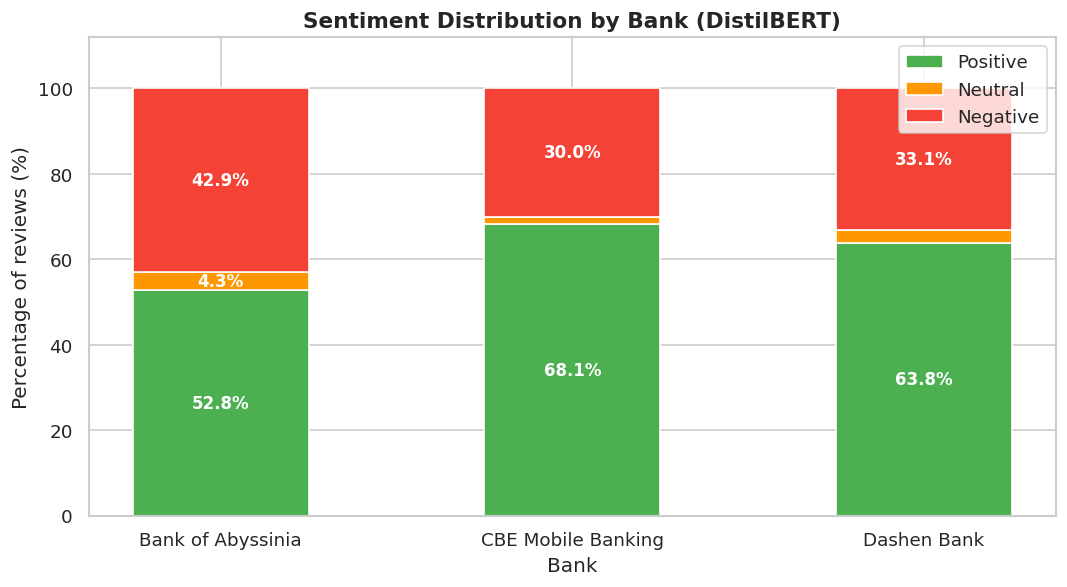

distilbert_label,positive,neutral,negative,total
bank,,,,
Bank of Abyssinia,258,21,210,489
CBE Mobile Banking,338,9,149,496
Dashen Bank,316,15,164,495


In [2]:
label_order = ['positive', 'neutral', 'negative']

bank_sent = (
    df.groupby(['bank', 'distilbert_label'])['review_id']
    .count().unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)
bank_pct = bank_sent.div(bank_sent.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bottoms = [0] * len(bank_pct)
for label in label_order:
    vals = bank_pct[label].values
    bars = ax.bar(bank_pct.index, vals, bottom=bottoms,
                  color=COLORS[label], label=label.capitalize(), width=0.5)
    for bar, val, bot in zip(bars, vals, bottoms):
        if val > 4:
            ax.text(bar.get_x() + bar.get_width()/2, bot + val/2,
                    f'{val:.1f}%', ha='center', va='center',
                    fontsize=10, color='white', fontweight='bold')
    bottoms = [b + v for b, v in zip(bottoms, vals)]

ax.set_title('Sentiment Distribution by Bank (DistilBERT)', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage of reviews (%)')
ax.set_xlabel('Bank')
ax.set_ylim(0, 112)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../data/processed/figures/fig1_sentiment_by_bank.png', bbox_inches='tight')
plt.show()

display(bank_sent.assign(total=bank_sent.sum(axis=1)))

---
## Plot 2 — Rating Distribution per Bank

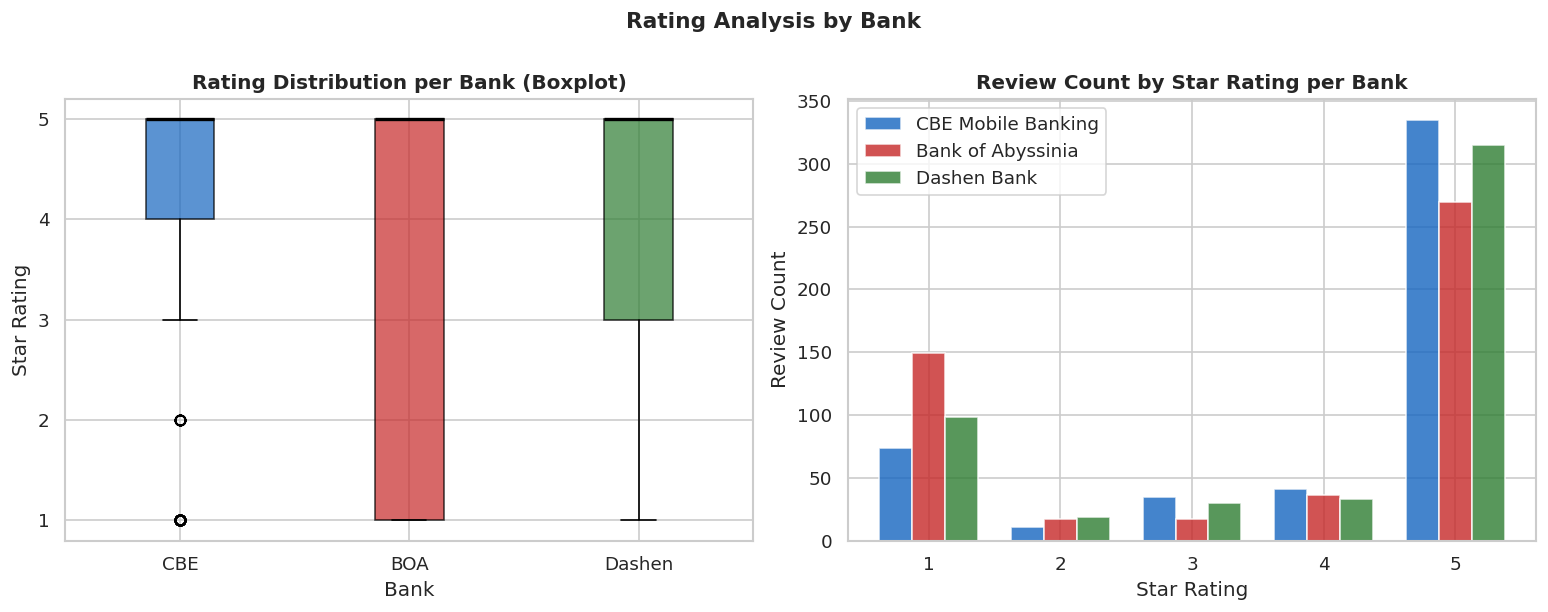

,count,mean,std,min,25%,50%,75%,max
bank,,,,,,,,
Bank of Abyssinia,489.0,3.53,1.80,1.0,1.0,5.0,5.0,5.0
CBE Mobile Banking,496.0,4.11,1.47,1.0,4.0,5.0,5.0,5.0
Dashen Bank,495.0,3.91,1.62,1.0,3.0,5.0,5.0,5.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
data_by_bank = [df[df['bank'] == b]['rating'].values for b in BANKS]
bp = axes[0].boxplot(data_by_bank, labels=['CBE', 'BOA', 'Dashen'],
                     patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], BCOLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Rating Distribution per Bank (Boxplot)', fontweight='bold')
axes[0].set_ylabel('Star Rating')
axes[0].set_xlabel('Bank')
axes[0].set_yticks(range(1, 6))

# Stacked histogram
rating_counts = (
    df.groupby(['bank', 'rating'])['review_id'].count()
    .unstack(fill_value=0)
)
x = np.arange(1, 6)
width = 0.25
for i, (bank, color) in enumerate(zip(BANKS, BCOLORS)):
    vals = [rating_counts.loc[bank, r] if r in rating_counts.columns else 0 for r in x]
    axes[1].bar(x + (i - 1) * width, vals, width, label=bank, color=color, alpha=0.8)
axes[1].set_title('Review Count by Star Rating per Bank', fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Review Count')
axes[1].set_xticks(x)
axes[1].legend()

plt.suptitle('Rating Analysis by Bank', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/figures/fig2_rating_distribution.png', bbox_inches='tight')
plt.show()

display(df.groupby('bank')['rating'].describe().round(2))

---
## Plot 3 — Theme Frequency per Bank

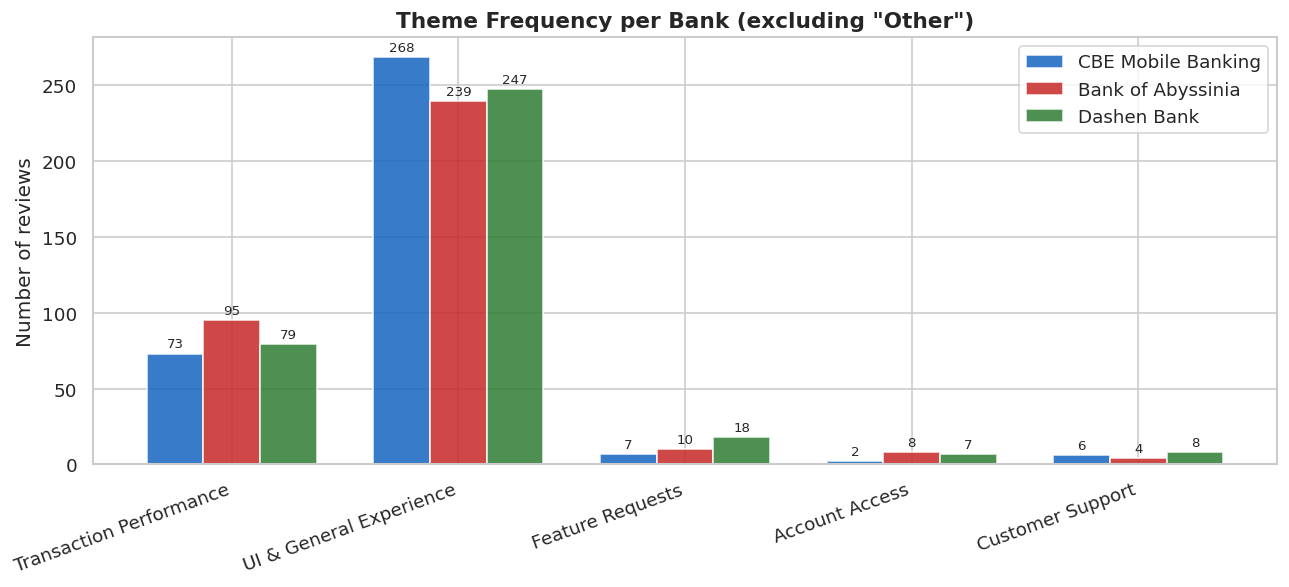

identified_theme,Transaction Performance,UI & General Experience,Feature Requests,Account Access,Customer Support
bank,,,,,
Bank of Abyssinia,95,239,10,8,4
CBE Mobile Banking,73,268,7,2,6
Dashen Bank,79,247,18,7,8


In [4]:
theme_order = ['Transaction Performance', 'UI & General Experience',
               'Feature Requests', 'Account Access', 'Customer Support']

theme_counts = (
    df[df['identified_theme'] != 'Other']
    .groupby(['bank', 'identified_theme'])['review_id']
    .count().unstack(fill_value=0)
    .reindex(columns=[t for t in theme_order if t in df['identified_theme'].unique()], fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(theme_order))
width = 0.25
for i, (bank, color) in enumerate(zip(BANKS, BCOLORS)):
    vals = [theme_counts.loc[bank, t] if t in theme_counts.columns else 0 for t in theme_order]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=bank, color=color, alpha=0.85)
    ax.bar_label(bars, padding=2, fontsize=8)

ax.set_title('Theme Frequency per Bank (excluding "Other")', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of reviews')
ax.set_xticks(x)
ax.set_xticklabels(theme_order, rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/figures/fig3_theme_frequency.png', bbox_inches='tight')
plt.show()

display(theme_counts)

---
## Plot 4 — Sentiment Trend Over Time

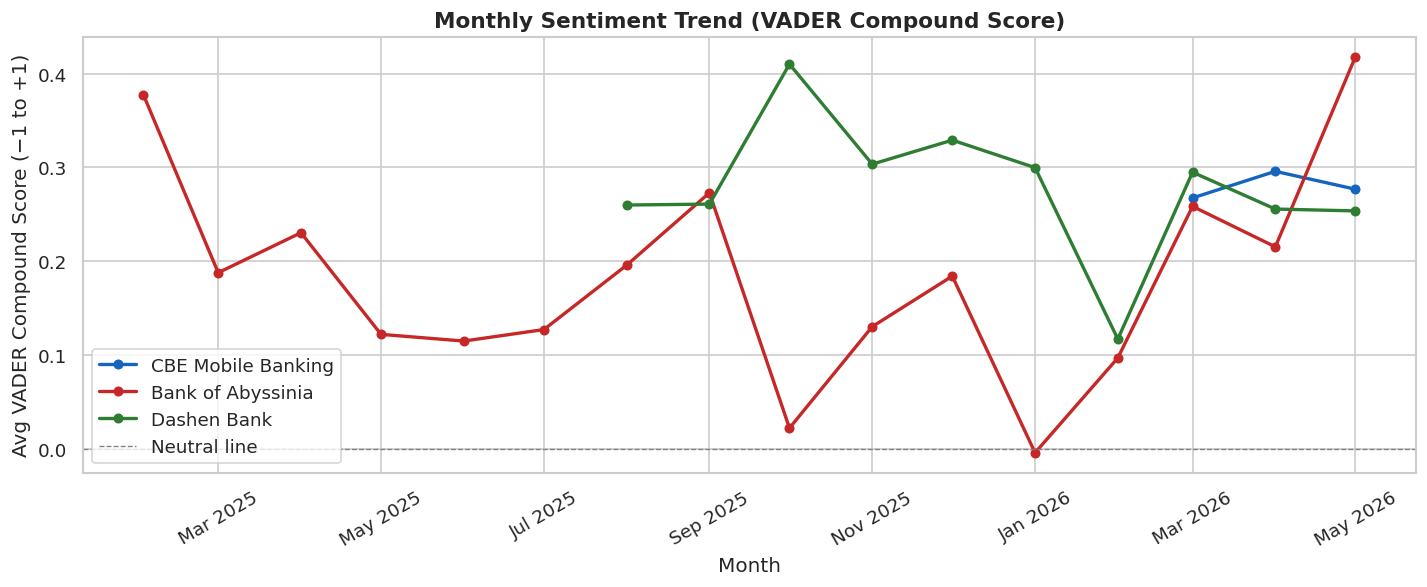

month,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05
bank,,,,,,,,,,,,,,,,
Bank of Abyssinia,0.377,0.188,0.23,0.122,0.115,0.127,0.196,0.273,0.022,0.130,0.184,-0.004,0.097,0.258,0.215,0.418
CBE Mobile Banking,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.267,0.296,0.277
Dashen Bank,NaN,NaN,NaN,NaN,NaN,NaN,0.260,0.261,0.410,0.304,0.329,0.300,0.117,0.295,0.256,0.254


In [5]:
monthly = (
    df.groupby(['bank', 'month'])['vader_score']
    .mean().reset_index()
)
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
for bank, color in zip(BANKS, BCOLORS):
    sub = monthly[monthly['bank'] == bank].sort_values('month_dt')
    ax.plot(sub['month_dt'], sub['vader_score'], marker='o',
            label=bank, color=color, linewidth=2, markersize=5)

ax.axhline(0, color='grey', linestyle='--', linewidth=0.8, label='Neutral line')
ax.set_title('Monthly Sentiment Trend (VADER Compound Score)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg VADER Compound Score (−1 to +1)')
ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../data/processed/figures/fig4_sentiment_trend.png', bbox_inches='tight')
plt.show()

display(
    df.groupby(['bank', 'month'])['vader_score']
    .mean().round(3).unstack().tail(5)
)

---
## Plot 5 — Top TF-IDF Keywords per Bank

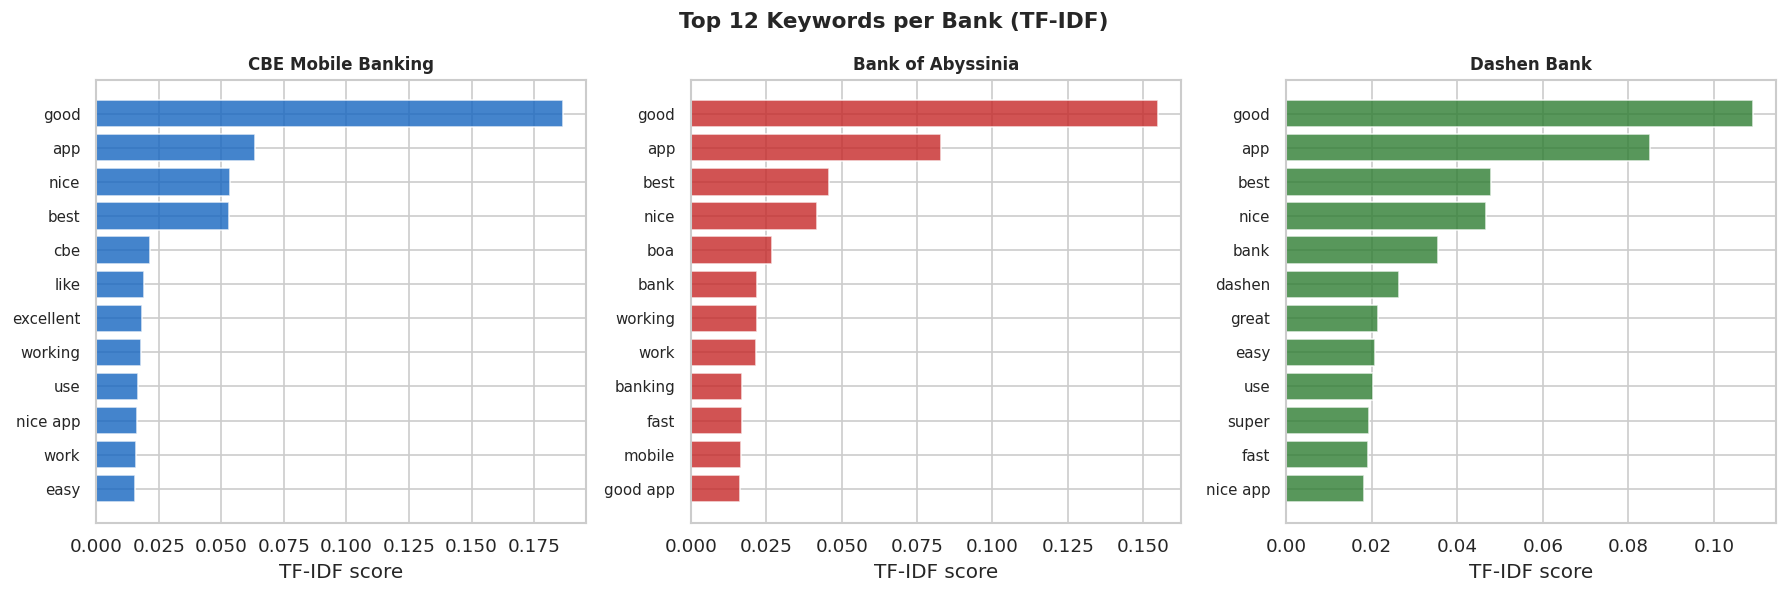

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, bank, color in zip(axes, BANKS, BCOLORS):
    kws = get_top_keywords(df, text_col='review_text', bank=bank, n=12)
    words  = [k for k, _ in kws]
    scores = [s for _, s in kws]
    y = range(len(words))
    ax.barh(y, scores, color=color, alpha=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(bank, fontweight='bold', fontsize=10)
    ax.set_xlabel('TF-IDF score')

plt.suptitle('Top 12 Keywords per Bank (TF-IDF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/figures/fig5_top_keywords.png', bbox_inches='tight')
plt.show()

---
## Bank-by-Bank Insights

### Methodology
Insights are derived from three evidence sources:
1. **DistilBERT sentiment labels** — positive / negative / neutral classification
2. **VADER compound scores** — continuous sentiment on −1 to +1 scale
3. **Keyword-based theme assignment** — 5 business themes from TF-IDF analysis

Satisfaction drivers are extracted from 5-star positive reviews. Pain points are extracted from 1–2 star negative reviews and negative-labelled reviews within specific themes.

In [7]:
# Cross-bank comparison table
comparison = pd.DataFrame({
    'avg_rating':       df.groupby('bank')['rating'].mean().round(2),
    'pct_positive':     (df.groupby('bank')['distilbert_label']
                         .apply(lambda x: (x=='positive').mean() * 100).round(1)),
    'pct_negative':     (df.groupby('bank')['distilbert_label']
                         .apply(lambda x: (x=='negative').mean() * 100).round(1)),
    'avg_vader':        df.groupby('bank')['vader_score'].mean().round(3),
    'top_theme':        df[df['identified_theme']!='Other'].groupby('bank')['identified_theme']
                         .agg(lambda x: x.value_counts().index[0]),
    'review_count':     df.groupby('bank')['review_id'].count(),
})
print('Cross-bank comparison:')
display(comparison)

Cross-bank comparison:


,avg_rating,pct_positive,pct_negative,avg_vader,top_theme,review_count
bank,,,,,,
Bank of Abyssinia,3.53,52.8,42.9,0.181,UI & General Experience,489
CBE Mobile Banking,4.11,68.1,30.0,0.284,UI & General Experience,496
Dashen Bank,3.91,63.8,33.1,0.293,UI & General Experience,495


---
### CBE Mobile Banking
**Overall:** Best performer — 68% positive, 4.11 avg rating, 496 reviews

#### Satisfaction Drivers
1. **Ease of use & reliable core functionality** — Users consistently praise the app's simplicity and speed for day-to-day transactions ("good to use", "best and secured", "easy"). TF-IDF top keywords include `easy`, `nice`, `working`, `excellent`.
2. **Transaction reliability** — The app handles transfers and airtime top-ups dependably for the majority of users, reflected in the highest average rating (4.11) and lowest negative rate (30%).

#### Pain Points
1. **Hidden transaction fees** — Negative reviews explicitly complain that fees are not shown before confirming transactions ("why is my transaction fee hidden?"). A transparency gap that erodes trust.
2. **UI regression after updates** — Users note the interface becomes "inconsistent" and "worse after every update", with non-functional features such as standing orders remaining broken across releases.

#### Recommendations
1. **Show fees before confirmation** — Display all transaction fees (transfer fees, VAT) on the review screen before the user confirms. A single-sprint change with high user-trust impact.
2. **Pre-release regression testing gate** — Enforce a UI consistency checklist before each release that covers previously reported broken features. Prevents the repeated regression complaints seen in reviews.

---
### Bank of Abyssinia (BOA)
**Overall:** Weakest performer — 53% positive, 43% negative, 3.56 avg rating, 489 reviews

#### Satisfaction Drivers
1. **App availability & broad feature set** — Despite the high negative rate, users acknowledge the app covers core banking needs ("BOA the best", "it's very good app"). The app exists and is functional for basic tasks.
2. **Branding loyalty** — Several 5-star reviews reflect loyalty to the Bank of Abyssinia brand rather than the app itself, suggesting an opportunity to convert brand loyalty into app satisfaction.

#### Pain Points
1. **Severe app slowness & unreliability** — The most common complaint: "extremely slow app and unreliable for most payment", "speed of app is very slow". Transaction Performance theme has 95 reviews — highest among all banks.
2. **Login & activation failures** — Users cannot log in after activation: "tried to open mobile app of BOA, but it can't work on my phone after activation". Account Access issues block new users before they make a single transaction.

#### Recommendations
1. **Performance optimisation sprint** — Profile and optimise the critical payment path end-to-end (network calls, DB queries, UI rendering). Target: reduce average transaction completion time by 50%. This single fix would address the largest complaint cluster.
2. **Fix the activation flow** — Conduct dedicated QA on the post-registration login flow across device models. Implement fallback activation via SMS OTP when app-based activation fails.

---
### Dashen Bank
**Overall:** Middle performer — 64% positive, 33% negative, 3.91 avg rating, 495 reviews

#### Satisfaction Drivers
1. **Modern design & ease of use** — Users praise the app's clean interface and speed ("smart app", "excellent", `fast`, `easy` in top keywords). UI & General Experience theme is the dominant positive category.
2. **Feature richness** — Dashen leads Feature Requests (18 reviews) — a sign that engaged, satisfied users want *more* from an app they already value, not that they want to leave.

#### Pain Points
1. **Slow app boot time & excessive update prompts** — "application booting time is so bad", "update request 3 times a month". Frequent forced updates interrupt sessions and erode daily usability.
2. **Unresponsive customer support** — Dashen has the highest Customer Support complaint rate (8 reviews): "they won't pick up, dialed repeatedly, waited on hold for 20 minutes". Trust breaks down when users cannot reach human support.

#### Recommendations
1. **Reduce update frequency & implement background updates** — Move to a monthly release cadence. Use silent background updates for non-critical patches so users are not interrupted mid-session.
2. **Expand customer support capacity** — Add in-app live chat or callback request feature to reduce call-centre load. Even a chatbot for common issues (OTP, balance inquiry) would reduce hold times and support ticket volume.

In [8]:
# Summary table — drivers, pain points, and recommendations
summary = pd.DataFrame([
    {
        'Bank': 'CBE Mobile Banking',
        'Driver 1': 'Ease of use & reliability',
        'Driver 2': 'Trusted transaction performance',
        'Pain Point 1': 'Hidden transaction fees',
        'Pain Point 2': 'UI regressions after updates',
        'Recommendation 1': 'Show fees before confirmation',
        'Recommendation 2': 'Pre-release regression testing gate',
    },
    {
        'Bank': 'Bank of Abyssinia',
        'Driver 1': 'Broad feature coverage',
        'Driver 2': 'Brand loyalty',
        'Pain Point 1': 'Severe slowness & unreliable payments',
        'Pain Point 2': 'Login/activation failures',
        'Recommendation 1': 'Performance optimisation sprint',
        'Recommendation 2': 'Fix activation flow with SMS OTP fallback',
    },
    {
        'Bank': 'Dashen Bank',
        'Driver 1': 'Modern design & speed',
        'Driver 2': 'Engaged users requesting more features',
        'Pain Point 1': 'Slow boot time & excessive updates',
        'Pain Point 2': 'Unresponsive customer support',
        'Recommendation 1': 'Monthly release cadence + background updates',
        'Recommendation 2': 'Add in-app live chat / callback feature',
    },
])
summary = summary.set_index('Bank')
print('Insights & Recommendations Summary:')
display(summary)

Insights & Recommendations Summary:


,Driver 1,Driver 2,Pain Point 1,Pain Point 2,Recommendation 1,Recommendation 2
Bank,,,,,,
CBE Mobile Banking,Ease of use & reliability,Trusted transaction performance,Hidden transaction fees,UI regressions after updates,Show fees before confirmation,Pre-release regression testing gate
Bank of Abyssinia,Broad feature coverage,Brand loyalty,Severe slowness & unreliable payments,Login/activation failures,Performance optimisation sprint,Fix activation flow with SMS OTP fallback
Dashen Bank,Modern design & speed,Engaged users requesting more features,Slow boot time & excessive updates,Unresponsive customer support,Monthly release cadence + background updates,Add in-app live chat / callback feature


---
## Figures saved
All plots saved to `data/processed/figures/`:
- `fig1_sentiment_by_bank.png`
- `fig2_rating_distribution.png`
- `fig3_theme_frequency.png`
- `fig4_sentiment_trend.png`
- `fig5_top_keywords.png`